## Initialize Spark Session

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ITR1_amritap1")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.executor.cores", "2")
    .config("spark.executor.instances", "2")
    .config("spark.serializer","org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer","256m")
    .config("spark.driver.maxResultSize","2g")
    .getOrCreate()
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/27 18:24:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Load Raw Data

In [2]:
commentsDF = spark.read.json("/home/amritap1/30123/final/comments")

In [3]:
submissionsDF = spark.read.json("/home/amritap1/30123/final/submissions")

25/10/27 18:24:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
commentsDF.printSchema()

root
 |-- approved_at_utc: string (nullable = true)
 |-- approved_by: string (nullable = true)
 |-- archived: boolean (nullable = true)
 |-- author: string (nullable = true)
 |-- author_cakeday: boolean (nullable = true)
 |-- author_created_utc: long (nullable = true)
 |-- author_flair_background_color: string (nullable = true)
 |-- author_flair_css_class: string (nullable = true)
 |-- author_flair_richtext: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- a: string (nullable = true)
 |    |    |-- e: string (nullable = true)
 |    |    |-- t: string (nullable = true)
 |    |    |-- u: string (nullable = true)
 |-- author_flair_template_id: string (nullable = true)
 |-- author_flair_text: string (nullable = true)
 |-- author_flair_text_color: string (nullable = true)
 |-- author_flair_type: string (nullable = true)
 |-- author_fullname: string (nullable = true)
 |-- author_patreon_flair: boolean (nullable = true)
 |-- banned_at_utc: string (nullabl

In [5]:
submissionsDF.printSchema()

root
 |-- approved_at_utc: string (nullable = true)
 |-- approved_by: string (nullable = true)
 |-- archived: boolean (nullable = true)
 |-- author: string (nullable = true)
 |-- author_cakeday: boolean (nullable = true)
 |-- author_created_utc: long (nullable = true)
 |-- author_flair_background_color: string (nullable = true)
 |-- author_flair_css_class: string (nullable = true)
 |-- author_flair_richtext: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- a: string (nullable = true)
 |    |    |-- e: string (nullable = true)
 |    |    |-- t: string (nullable = true)
 |    |    |-- u: string (nullable = true)
 |-- author_flair_template_id: string (nullable = true)
 |-- author_flair_text: string (nullable = true)
 |-- author_flair_text_color: string (nullable = true)
 |-- author_flair_type: string (nullable = true)
 |-- author_fullname: string (nullable = true)
 |-- author_patreon_flair: boolean (nullable = true)
 |-- banned_at_utc: string (nullabl

## Data Cleaning

I implemented a two-step cleaning process:
1. **Remove bot accounts** - Filter out automoderator, bot, and moderator accounts
2. **Remove deleted content** - Drop `[deleted]` and `[removed]` posts

Keeping bots would artificially inflate certain ticker associations (e.g., automated stock updates), making the patterns less meaningful for understanding organic user discussions.

In [6]:
from pyspark.sql import functions as F

def remove_bot_accounts(df):
    a = F.lower(F.col("author"))
    is_bot = F.coalesce(
        a.contains("automoderator") | a.contains("moderator") | a.contains("bot") | a.contains("automod"),
        F.lit(False)
    )
    df = df.filter(~is_bot)
    return df

In [7]:
commentsDF = remove_bot_accounts(commentsDF)
submissionsDF = remove_bot_accounts(submissionsDF)

In [8]:
from pyspark.sql import functions as F

def remove_deleted_content(df, text_column):
    df = df.filter(
        F.col(text_column).isNotNull() &
        ~F.col(text_column).isin("[deleted]", "[removed]")
    )
    return df

In [9]:
commentsDF = remove_deleted_content(commentsDF, 'body')
submissionsDF = remove_deleted_content(submissionsDF, 'selftext')

## Data Preparation

### Text Cleaning
Clean text by:
- Converting HTML
- Removing URLs and markdown links
- Avoid multiple whitespaces
- Removing zero-width characters
- Converting to lowercase

### Removing Stopwords
Using default English stopwords plus domain-specific terms like "reddit", "wsb", "wallstreetbets" that appear frequently but don't distinguish topics. Keeping ticker symbols and financial terms intact.

### Process Submissions and Comments
- Convert timestamps to datetime format
- Filter by date range and valid authors
- Concatenate title + selftext for submissions and body for comments for the entire text
- Add document metadata

In [10]:
t0  = F.to_timestamp(F.lit("2014-01-01"))
t1  = F.to_timestamp(F.lit("2018-12-31 23:59:59"))

In [ ]:
@F.udf("string")
def clean_text(s):
    if not s: return None
    import re
    s = re.sub(r"&amp;","&", s)
    s = re.sub(r"\[.*?\]\(https?://\S+\)"," ", s)
    s = re.sub(r"https?://\S+"," ", s)
    s = re.sub(r"[^\S\r\n]+"," ", s)
    s = re.sub(r"[\u200b-\u200d\uFEFF]","", s)
    return s.strip().lower()

In [12]:
from pyspark.sql import functions as F, types as T
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

In [ ]:
extra_stops = ["amp","reddit","wsb","wallstreetbets","rt","tl;dr","edit"]
base_stops = StopWordsRemover.loadDefaultStopWords("english")
stopwords = list(set(base_stops + extra_stops))

In [ ]:
posts = (submissionsDF
  .withColumn("created_ts",
      F.coalesce(F.from_unixtime(F.col("created").cast("double")).cast("timestamp"),
                 F.to_timestamp(F.col("created_utc"))))
  .filter((F.col("created_ts")>=t0) & (F.col("created_ts")<=t1))
  .filter(~F.lower(F.col("author")).isin("[deleted]","[removed]"))
  .withColumn("raw_text", F.concat_ws(" ", F.col("title"), F.col("selftext")))
  .filter(F.col("raw_text").isNotNull() & (F.length("raw_text")>0))
  .withColumn("text", clean_text("raw_text"))
  .select(
      F.col("id").alias("doc_id"),
      F.lit("post").alias("doc_type"),
      "author","created_ts","score","num_comments","permalink","url",
      F.col("link_flair_text").alias("flair"),
      "text"
  )
  .dropDuplicates(["doc_id"])
)

In [ ]:
comments = (commentsDF
  .withColumn("created_ts",
      F.coalesce(F.from_unixtime(F.col("created").cast("double")).cast("timestamp"),
                 F.to_timestamp(F.col("created_utc"))))
  .filter((F.col("created_ts")>=t0) & (F.col("created_ts")<=t1))
  .filter(~F.lower(F.col("author")).isin("[deleted]","[removed]"))
  .filter(~F.lower(F.col("body")).isin("[deleted]","[removed]"))
  .withColumn("text", clean_text("body"))
  .select(
      F.col("id").alias("doc_id"),
      F.lit("comment").alias("doc_type"),
      "author","created_ts","score",
      F.lit(None).cast("long").alias("num_comments"),
      "permalink",
      F.lit(None).cast("string").alias("url"),
      F.lit(None).cast("string").alias("flair"),
      "text"
  )
  .dropDuplicates(["doc_id"])
)

In [ ]:
docs = posts.unionByName(comments)

### Add Temporal Features
Adding year, quarter, month, and months_since_start for time-series analysis.

Filter out very short texts (< 5 chars).

In [17]:
docs = (docs
  .withColumn("year", F.year("created_ts"))
  .withColumn("quarter", F.quarter("created_ts"))
  .withColumn("month", F.month("created_ts"))
  .withColumn("months_since_start",
              F.round(F.months_between(F.col("created_ts"), F.to_timestamp(F.lit("2014-01-01"))), 1))
  .filter(F.col("text").isNotNull() & (F.length("text") >= 5))
)

### Tokenization and Stopword Removal
Using regex tokenizer to extract:
- Ticker symbols (e.g., $AAPL)
- Words with 2+ letters
- Handling hyphens and apostrophes in words

Then removing stopwords to focus on terms with contents.

In [ ]:
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern=r"(?u)(?:\$?[A-Za-z]{2,5}|[A-Za-z][\w'-]{2,})",
    gaps=False,              
    toLowercase=True
)
tok_temp = tokenizer.transform(docs)

tok_temp = tok_temp.withColumn(
    "tokens_clean_temp",
    F.expr("""filter(tokens, x -> x rlike '(?i)^(\\$[A-Z]{2,5}|[a-z]{3,}([\\'-][a-z]+)*)$')""")
)
remover   = StopWordsRemover(inputCol="tokens_clean_temp", outputCol="tokens_clean", stopWords=stopwords)
tok = remover.transform(tok_temp)

### Final Filtering
Ensure at least 3 tokens per document to ensure sufficient content.

In [ ]:
cleanDF = (tok
  .withColumn("tok_len", F.size("tokens_clean"))
  .filter(F.col("tok_len") >= 3)
  .drop("tok_len")
)

## TF-IDF Vectorization

In [ ]:
from pyspark.ml.feature import CountVectorizer, IDF

cv = CountVectorizer(
    inputCol="tokens_clean",
    outputCol="termFreq",
    vocabSize=1000,
    minDF=50,
    binary=False
)
cv_model = cv.fit(cleanDF)
tfDF = cv_model.transform(cleanDF)

In [ ]:
idf = IDF(inputCol="termFreq", outputCol="features_tfidf")
idf_model = idf.fit(tfDF)
tfidfDF = idf_model.transform(tfDF).select(
    "doc_id","doc_type","author","created_ts","year","quarter","month","months_since_start",
    "score","num_comments","flair","features_tfidf"
)

In [ ]:
print("Vocab size:", len(cv_model.vocabulary))
tfidfDF.show(3, truncate=False)

Vocab size: 1000


[Stage 20:=====================================================>  (24 + 1) / 25]

+------+--------+-------------+-------------------+----+-------+-----+------------------+-----+------------+-----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Principal Component Analysis (PCA)

In [23]:
from pyspark.ml.feature import PCA
pca = PCA(k=20, inputCol="features_tfidf", outputCol="pcaFeatures")
pca_model = pca.fit(tfidfDF)
pcaDF = pca_model.transform(tfidfDF)

25/10/27 18:25:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [ ]:
explained = pca_model.explainedVariance.toArray()
print("Explained variance (first 10 comps):", explained[:10])
print("Total variance captured:", explained.sum())

Explained variance (first 10 comps): [0.09580134 0.02474145 0.01905272 0.01573269 0.01351223 0.01252032
 0.01100446 0.00998684 0.0087626  0.00850732]
Total variance captured: 0.28505746031644635


In [25]:
pcaDF.select("doc_id","year","months_since_start","pcaFeatures").show(3, truncate=False)

[Stage 45:=====================================================>  (24 + 1) / 25]

+------+----+------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|doc_id|year|months_since_start|pcaFeatures                                                                                                                                                                                                                                                                                                                                                                                                    |
+------+----+------------------+------------------------------------------------------------------------------------------------------

In [26]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

K = range(2, 11)
cost = []

for k in K:
    km = KMeans(k=k, seed=42, featuresCol="pcaFeatures", predictionCol="cluster")
    model = km.fit(pcaDF)
    cost.append(model.summary.trainingCost)
    pred = model.transform(pcaDF)
    evalr = ClusteringEvaluator(featuresCol="pcaFeatures", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")
    score = evalr.evaluate(pred)
    print(f"k={k}, silhouette={score:.4f}")

25/10/27 18:26:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/10/27 18:26:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

k=2, silhouette=0.9972


k=3, silhouette=0.9261


k=4, silhouette=0.9693


k=5, silhouette=0.9131


...

k=7, silhouette=0.9272


k=8, silhouette=0.9243


k=9, silhouette=0.7755


[Stage 1155:==========================================>             (3 + 1) / 4]

k=10, silhouette=0.9163


## K-Means Clustering

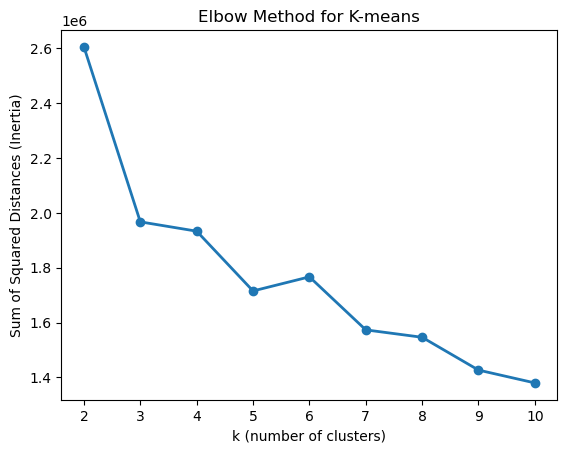

In [27]:
import matplotlib.pyplot as plt

plt.plot(K, cost, 'o-', linewidth=2)
plt.xlabel('k (number of clusters)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method for K-means')
plt.show()

In [ ]:
bestK = 3
kmeans = KMeans(k=bestK, seed=42, featuresCol="pcaFeatures", predictionCol="cluster")
kModel = kmeans.fit(pcaDF)
clusteredDF = kModel.transform(pcaDF)

## Cluster Characterization

### Cluster Statistics
Examining cluster sizes and average metrics to understand what differentiates the clusters.

In [ ]:
clusteredDF.groupBy("cluster").agg(
    F.count("*").alias("count"),
    F.avg("score").alias("avg_score"),
    F.avg("num_comments").alias("avg_comments"),
    F.avg("months_since_start").alias("avg_months")
).orderBy("cluster").show()

[Stage 1286:=================================>                      (3 + 2) / 5]

+-------+-----+------------------+------------------+------------------+
|cluster|count|         avg_score|      avg_comments|        avg_months|
+-------+-----+------------------+------------------+------------------+
|      0|15648| 42.42510224948875|16.530554664956718|31.342043711656494|
|      1|  561|40.959001782531196|22.808586762075134|26.044028520499115|
|      2|   34| 94.79411764705883|              40.5|25.929411764705886|
+-------+-----+------------------+------------------+------------------+



### Top Terms Per Cluster
Extracting the 15 highest-weighted terms reveals the themes of the content that defines each cluster.

In [ ]:
from pyspark.ml.stat import Summarizer
import numpy as np

joined = tfidfDF.join(clusteredDF.select("doc_id","cluster"), "doc_id")

s = Summarizer.metrics("mean")
means = (joined.groupBy("cluster")
         .agg(s.summary(F.col("features_tfidf")).alias("summ"))
         .select("cluster", F.col("summ.mean").alias("avg_vec"))
         .orderBy("cluster"))

vocab = cv_model.vocabulary
top_n = 15

for row in means.collect():
    arr = row["avg_vec"].toArray()
    idxs = np.argsort(arr)[-top_n:][::-1]
    terms = [vocab[i] for i in idxs]
    print(f"Cluster {row['cluster']}: {', '.join(terms)}")

Cluster 0: ing, stock, earni, ngs, calls, marke, think, like, today, buy, optio, short, trade, anyon, yolo
Cluster 1: compa, stock, price, ing, share, marke, optio, trade, year, becau, also, ion, like, inves, month
Cluster 2: compa, milli, share, price, nts, drug, fda, warra, appro, reven, data, ing, trial, inves, stock


### Cluster Evolution Over Time
Tracking how cluster prevalence changes from 2014-2018. This reveals:
- How and what topics became more/less popular over time
- Major events that might have shifted discussion themes

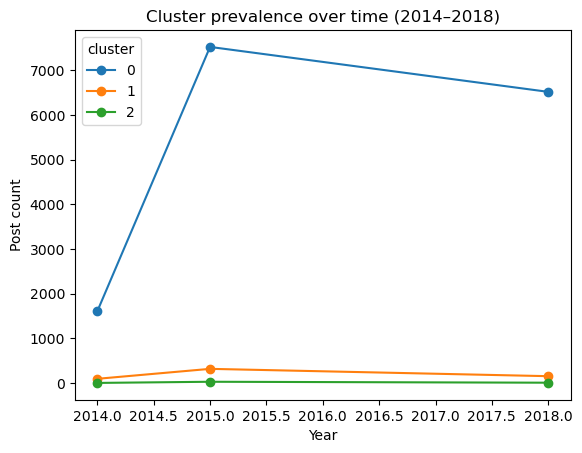

In [ ]:
trend = (clusteredDF
    .groupBy("year","cluster")
    .count()
    .toPandas()
    .pivot(index="year", columns="cluster", values="count")
    .fillna(0))

trend.plot(kind="line", marker="o")
plt.title("Cluster prevalence over time (2014–2018)")
plt.xlabel("Year")
plt.ylabel("Post count")
plt.show()

## Summary

### Outcomes

Three clusters were created.

**Cluster 0**: Has the highest number of submissions (15648 entries), and represents daily discussions. Top terms include "calls," "optio[ns]," "short," "earni[ngs]," and "today", terms that are basic components of trading discourse. This cluster also includes interaction-related terms like "think," "like," "anyon[e]", which also points to standard discussions within the community.

**Cluster 1**: The keywords here represent deeper financial analysis. Terms include "compa[ny]," "share," "price," "year," "month," and "inves[tment]", which indicate that this cluster corresponds to discussions related to a company's valuation and performance. These also involve more comments (22.8 vs 16.5 for cluster 0), which might hint at more debate.

**Cluster 2**: Smallest cluster, but contains keywords like "drug," "fda," "trial," "appro[val]," and "warra[nts]", which hint at discussions about biological firms. This also demonstrates higher engagement (both in points and comments). This might indicate that high stake opportunites spark more interest, or it might be a result of some major events during the time, for which further research is required.


### Challenges

The biggest challenge was the performance on TF-IDF and PCA with stronger parameters. I ran into various memory issues while performing this experiment - initially testing with a vocab size of 5000 and 10000, minDF of 5 and 10, and 50 PCA components. I was only able to obtain a result for a vocab size of 1000, minDF 50 and k=20 components, which only captured 28.5% of the variance. While this can be considered for broad thematic patterns, further analysis on this data could provide additional key insights on nuanced information in the data.